In [9]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [10]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = workcomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "Chrimson2"
respondercsv = responder + ".csv"
wt = "w1118"


In [11]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Fira Mono"

In [12]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## Function

In [13]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

def wrap_labels(ax, width, break_long_words=False):
    import textwrap
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

# Heatmap

## Heatmap (2 responders)

In [5]:
newfile2 = openPath + "Compilation with delta\\2025meandiffcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" ")[2]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps


In [6]:
#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)
onlymeans

,MBON,fallprop_deltag,fallnumber_deltag,speed_deltag,time_deltag,height_deltag,displacement_deltag,bspeed_deltag,pausepos_deltag,displacementbetweenpause_deltag,maxvelocity_deltag,straightindex_deltag,ascent_deltag,descent_deltag,meanpause_deltag,meanbout_deltag,pause_deltag,bout_deltag,responder,genotypeandresponder
0,MB011B,0.081,0.090,-0.028,0.262,0.243,-0.017,0.166,0.201,0.304,-0.242,0.104,0.089,-0.051,0.319,0.126,-0.114,-0.095,ACR,MB011B_ACR
1,MB011B,0.140,-0.150,-0.058,-0.054,0.165,-0.035,0.034,0.382,0.202,0.782,0.532,0.003,-0.133,0.117,0.082,-0.290,-0.303,Chrimson2,MB011B_Chrimson2
2,MB018B,-0.175,-0.339,-0.149,-0.056,-0.242,-0.134,-0.040,-0.433,0.309,-1.405,0.892,-0.590,0.394,0.550,0.315,-0.430,-0.424,ACR,MB018B_ACR
3,MB018B,-0.022,0.076,-0.350,0.118,0.293,-0.400,0.184,0.336,0.012,0.412,0.210,-0.152,-0.453,0.523,0.146,-0.372,-0.384,Chrimson2,MB018B_Chrimson2
4,MB027B,-0.063,0.014,-0.300,0.178,0.127,-0.301,-0.109,-0.039,0.027,-0.496,-0.037,-0.230,-0.244,0.260,0.126,0.013,-0.019,ACR,MB027B_ACR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,SS97567,-0.102,-0.125,-0.165,-0.412,-0.291,-0.176,0.143,-0.121,0.176,-0.428,0.098,0.045,-0.251,0.477,0.297,-0.549,-0.506,Chrimson2,SS97567_Chrimson2
91,Th-Gal4,-0.032,-0.273,-0.527,0.190,-0.008,-0.670,-0.102,-0.154,-0.219,-0.068,-0.738,-0.517,-0.513,0.424,-0.038,-0.072,-0.177,ACR,Th-Gal4_ACR
92,Th-Gal4,0.603,1.547,-0.304,-0.207,-0.390,-0.499,-0.703,-0.551,-0.698,-0.132,0.330,0.141,-0.909,-0.479,0.029,0.378,0.361,Chrimson2,Th-Gal4_Chrimson2
93,VT999036,-0.060,-0.053,-1.768,-0.544,-0.346,-1.752,-0.046,-0.597,-0.796,-1.606,0.771,-1.724,-1.009,1.415,-0.574,-0.916,-1.027,ACR,VT999036_ACR


In [7]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

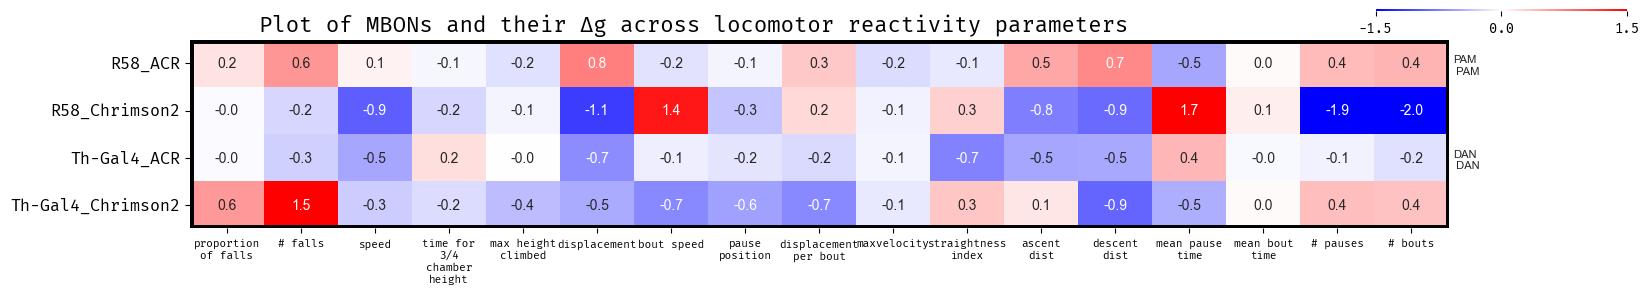

In [9]:
#only specific mbon list with both ACR and Chrimson2
from collections import Counter
counts = Counter(onlymeans['MBON'].to_list())
matchingsets = [value for value, count in counts.items() if count > 1]
matchdf = onlymeans[onlymeans['MBON'].str.contains("|".join(matchingsets), regex= True)]

#specificlist
lstofmbonsiwant = ["R58" , "Th-Gal4"]
df00 = pd.DataFrame()
for n in lstofmbonsiwant:
    df00 = pd.concat([df00, matchdf[matchdf['MBON'] == n]])


#continue here
# df00 = matchdf.copy()
df00.columns = df00.columns.str.replace('_deltag', '')
df50 = df00.set_index(['genotypeandresponder'])

df50 = df50.drop(['MBON', 'responder'], axis =1)

fig1, ax3 = plt.subplots(figsize=(15, 3))     
#adding extra axes label
lobloclst = []
mbonloclst = []
df500 = df00.copy()
for n in df00['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df500['Lobe'] = lobloclst
df500['Name'] = mbonloclst

#labelling of MBON number and location but ONLY ifc comparing ACR and CHRIMSON2

newdf500 = pd.DataFrame()
naming = df500['Name'].iloc[::2].to_frame().rename(columns = {"Name": ""})
lobing = df500['Lobe'].iloc[1::2].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf500['Merge'] = newlabel

#new labels for heatmap
xticklabeldf = df00.rename(columns={'bspeed': 'bout speed', 'pausepos': 'pause position', 'boutpos': 'bout position', 'displacementbetweenpause': 'displacement per bout', 'ascent': 'ascent dist',
                     'descent': 'descent dist', 'meanpause': 'mean pause time', 'meanbout': 'mean bout time', 'pause': '# pauses', 'bout': '# bouts', 'fallnumber': '# falls', 
                     'fallprop': "proportion of falls", 'straightindex': 'straightness index', 'time': 'time for 3/4 chamber height', 'height': 'max height climbed'})

xticklabellist = xticklabeldf.columns[1:-2].tolist()

#for individual points, not merging of ACR and Chrimson2 (i.e. different genotypes)
# newdf500 = pd.DataFrame()
# naming = df500['Name'].to_frame().rename(columns = {"Name": ""})
# lobing = df500['Lobe'].to_frame().rename(columns = {"Lobe": ""})
# newlabel =(naming.values + "\n " + lobing.values).tolist()
# newdf500['Merge'] = newlabel

#colorbar
cax = inset_axes(ax3,
                 width="20%",  # width: 40% of parent_bbox width
                 height="1%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.3, 1, 1),
                 bbox_transform=ax3.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})           
j7 = sns.heatmap(df50, ax = ax3, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap='bwr', linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=True
                 , clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5, 0 ,1.5]), annot_kws={"size": 10}) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 12)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 30, fontsize = 8)
wrap_labels(j7, 10)

# Drawing the overall frame 
j7.axhline(y = 0, color = 'k',  
            linewidth = 5) 
  
j7.axhline(y = 4, color = 'k',   
            linewidth = 5) #72 for max
  
j7.axvline(x = 0, color = 'k', 
            linewidth = 5) 
  
j7.axvline(x = 17, color = 'k',  #11
            linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())
j8.tick_params(length=0)

#y labels for mbon lobes and naming
labellinglist = newdf500['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(("", n[0]))  #inserts blank space after every list name
    #labelledlist.extend(n)     #either or
    
#j8.set_yticklabels(newdf500['Merge'].iloc[::-1], fontsize=10)
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)


j7.set_title('Plot of MBONs and their Δg across locomotor reactivity parameters', x=0.4, weight='bold', fontsize =16 )

fig1.tight_layout()

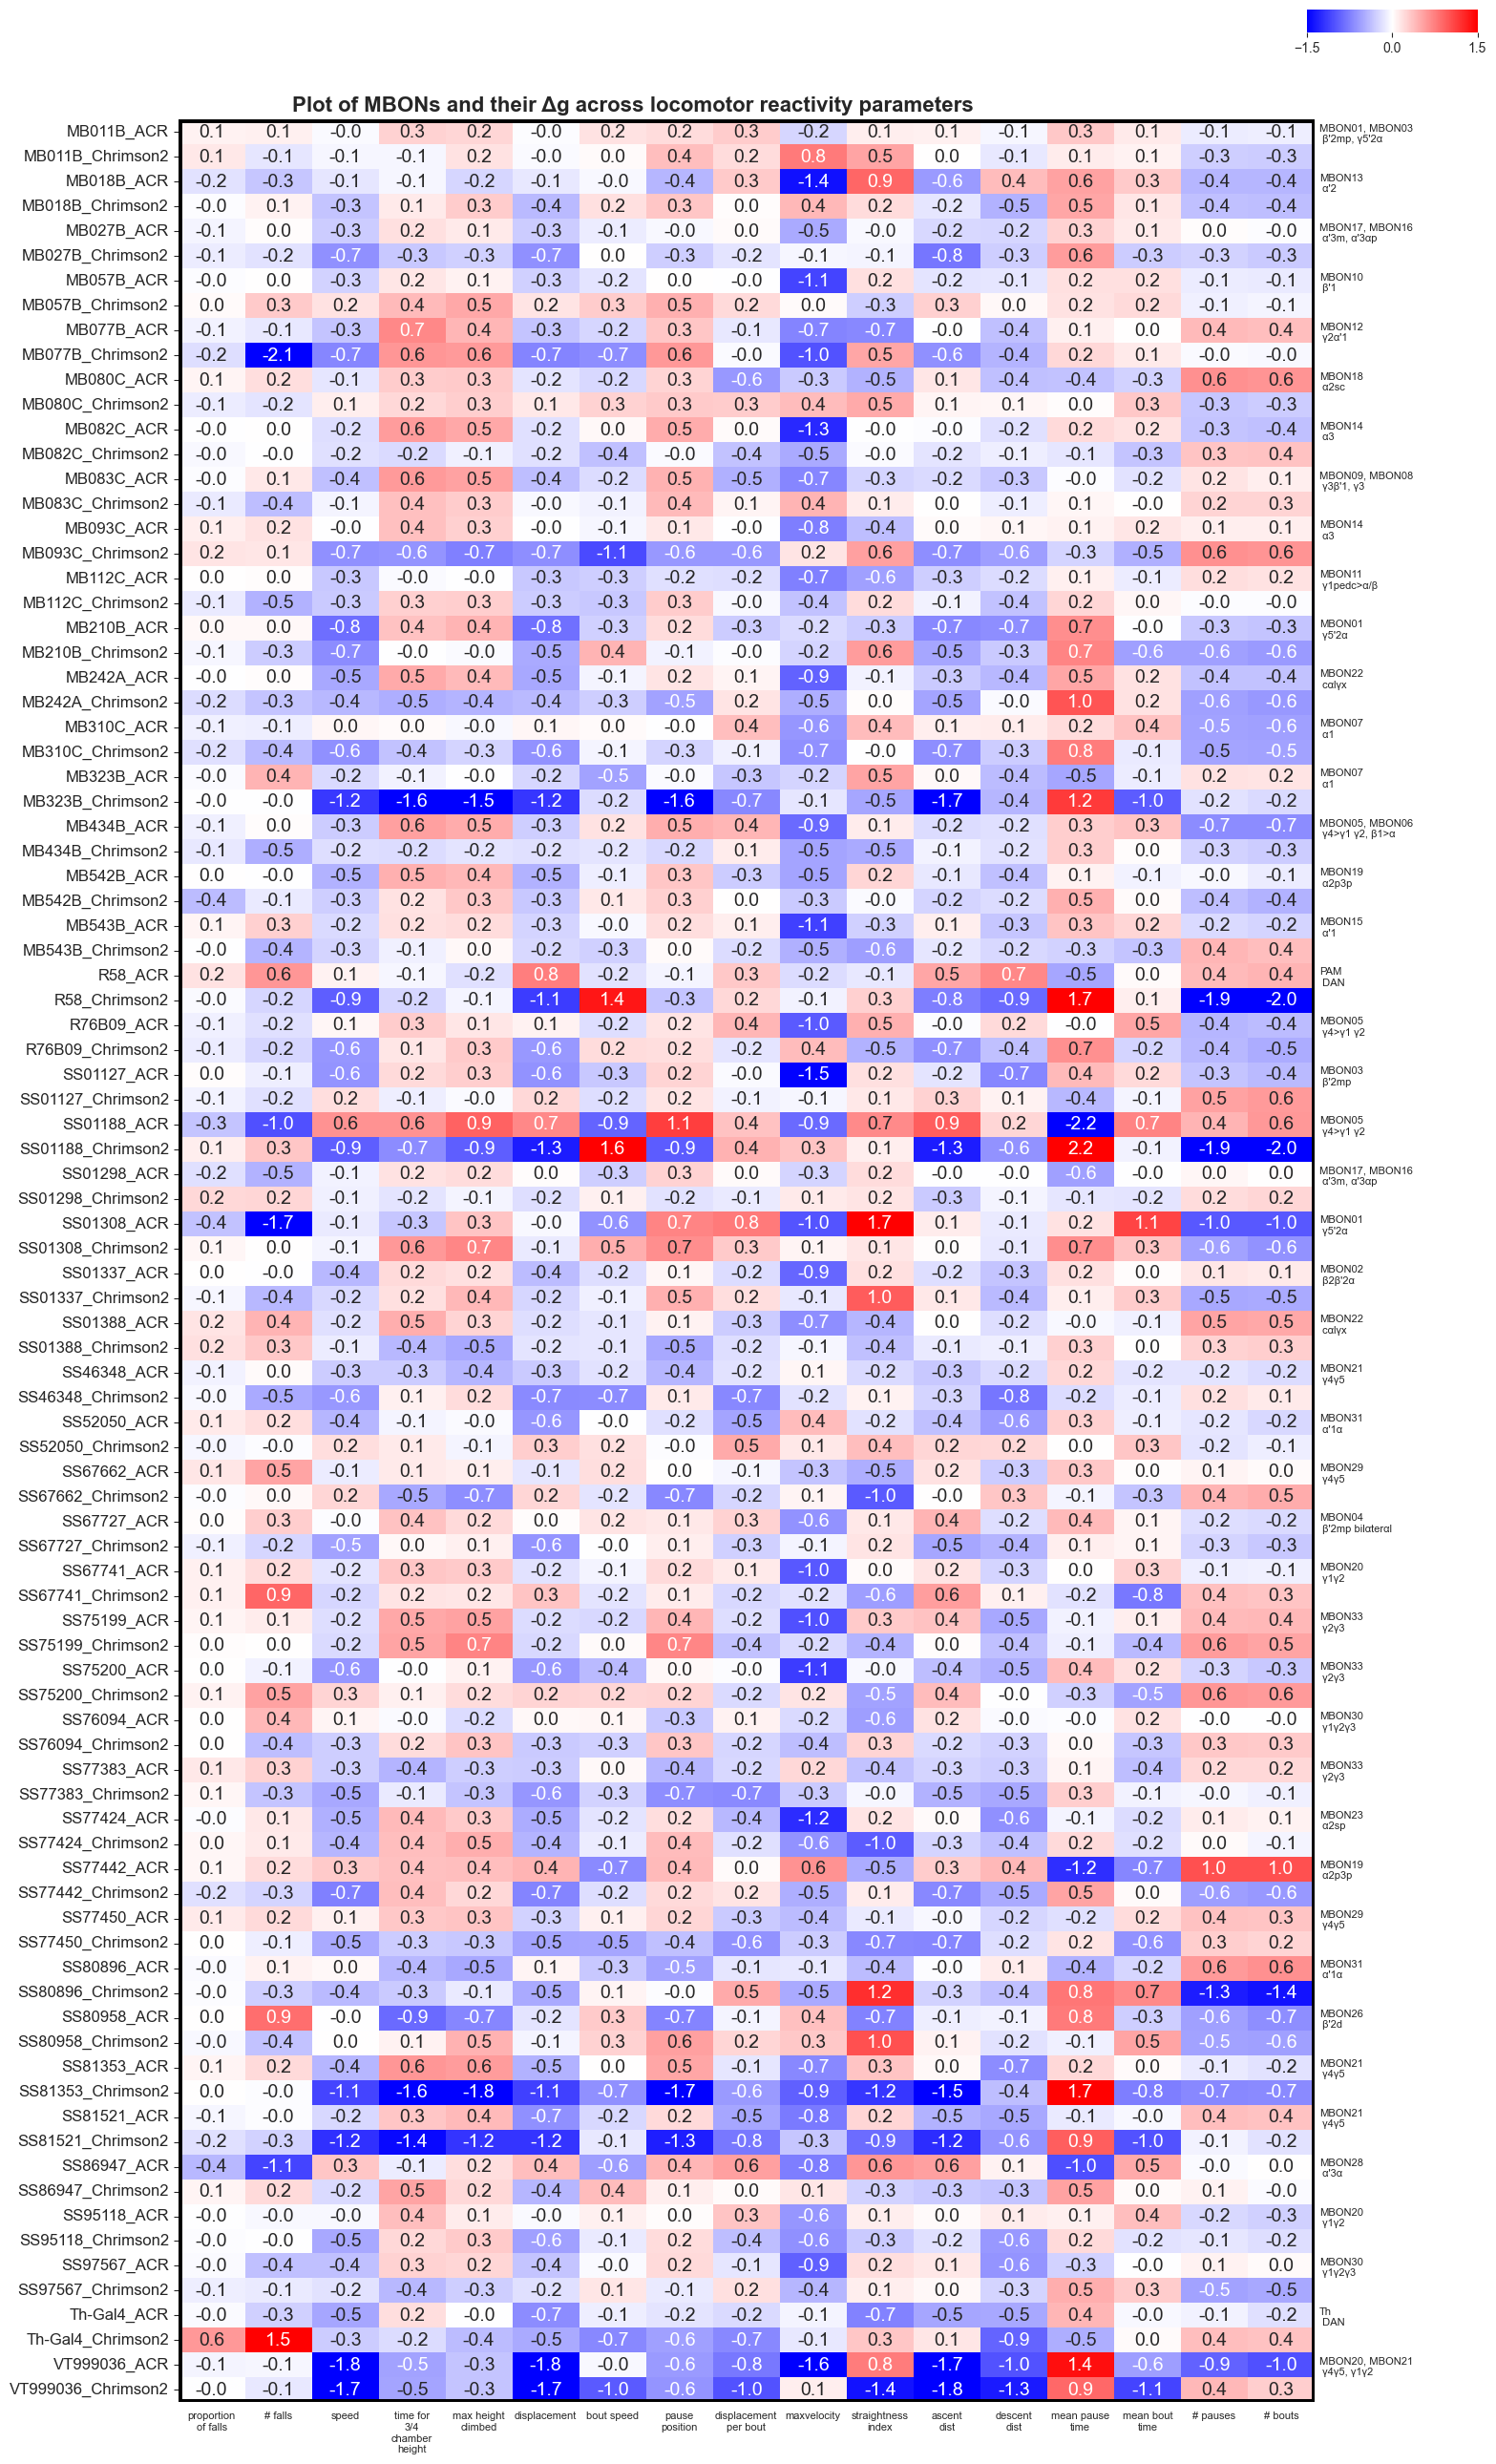

In [ ]:
#total mbon list including ACR and chrimson2
from collections import Counter
counts = Counter(onlymeans['MBON'].to_list())
matchingsets = [value for value, count in counts.items() if count > 1]
matchdf = onlymeans[onlymeans['MBON'].str.contains("|".join(matchingsets), regex= True)]

#continue here
df00 = matchdf.copy()
df00.columns = df00.columns.str.replace('_deltag', '')
df50 = df00.set_index(['genotypeandresponder'])

df50 = df50.drop(['MBON', 'responder'], axis =1)

fig1, ax3 = plt.subplots(figsize=(15, 25))     
#adding extra axes label
lobloclst = []
mbonloclst = []
df500 = df00.copy()
for n in df00['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df500['Lobe'] = lobloclst
df500['Name'] = mbonloclst

#labelling of MBON number and location but ONLY ifc comparing ACR and CHRIMSON2

newdf500 = pd.DataFrame()
naming = df500['Name'].iloc[::2].to_frame().rename(columns = {"Name": ""})
lobing = df500['Lobe'].iloc[1::2].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf500['Merge'] = newlabel

#new labels for heatmap
xticklabeldf = df00.rename(columns={'bspeed': 'bout speed', 'pausepos': 'pause position', 'boutpos': 'bout position', 'displacementbetweenpause': 'displacement per bout', 'ascent': 'ascent dist',
                     'descent': 'descent dist', 'meanpause': 'mean pause time', 'meanbout': 'mean bout time', 'pause': '# pauses', 'bout': '# bouts', 'fallnumber': '# falls', 
                     'fallprop': "proportion of falls", 'straightindex': 'straightness index', 'time': 'time for 3/4 chamber height', 'height': 'max height climbed'})

xticklabellist = xticklabeldf.columns[1:-2].tolist()

#for individual points, not merging of ACR and Chrimson2 (i.e. different genotypes)

# newdf500 = pd.DataFrame()
# naming = df500['Name'].to_frame().rename(columns = {"Name": ""})
# lobing = df500['Lobe'].to_frame().rename(columns = {"Lobe": ""})
# newlabel =(naming.values + "\n " + lobing.values).tolist()
# newdf500['Merge'] = newlabel

#colorbar
cax = inset_axes(ax3,
                 width="15%",  # width: 40% of parent_bbox width
                 height="1%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.02, 1, 1),
                 bbox_transform=ax3.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})           
j7 = sns.heatmap(df50, ax = ax3, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap='bwr', linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=True
                 , clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5, 0 ,1.5]), annot_kws={"size": 14}) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 12)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 0, fontsize = 8)
wrap_labels(j7, 10)

# Drawing the overall frame 
j7.axhline(y = 0, color = 'k',  
            linewidth = 5) 
  
j7.axhline(y = 92, color = 'k',   
            linewidth = 5) #72 for max
  
j7.axvline(x = 0, color = 'k', 
            linewidth = 5) 
  
j7.axvline(x = 17, color = 'k',  #11
            linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())
j8.tick_params(length=0)

#y labels for mbon lobes and naming
labellinglist = newdf500['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(("", n[0]))  #inserts blank space after every list name
    #labelledlist.extend(n)     #either or
    
#j8.set_yticklabels(newdf500['Merge'].iloc[::-1], fontsize=10)
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)


j7.set_title('Plot of MBONs and their Δg across locomotor reactivity parameters', x=0.4, weight='bold', fontsize =16 )

fig1.tight_layout()

plt.savefig(openPath + "images\\" + date + "_ACRChrimson2_deltagheatmapwithlobelocations.png", dpi = 1200)

weighted euclidean


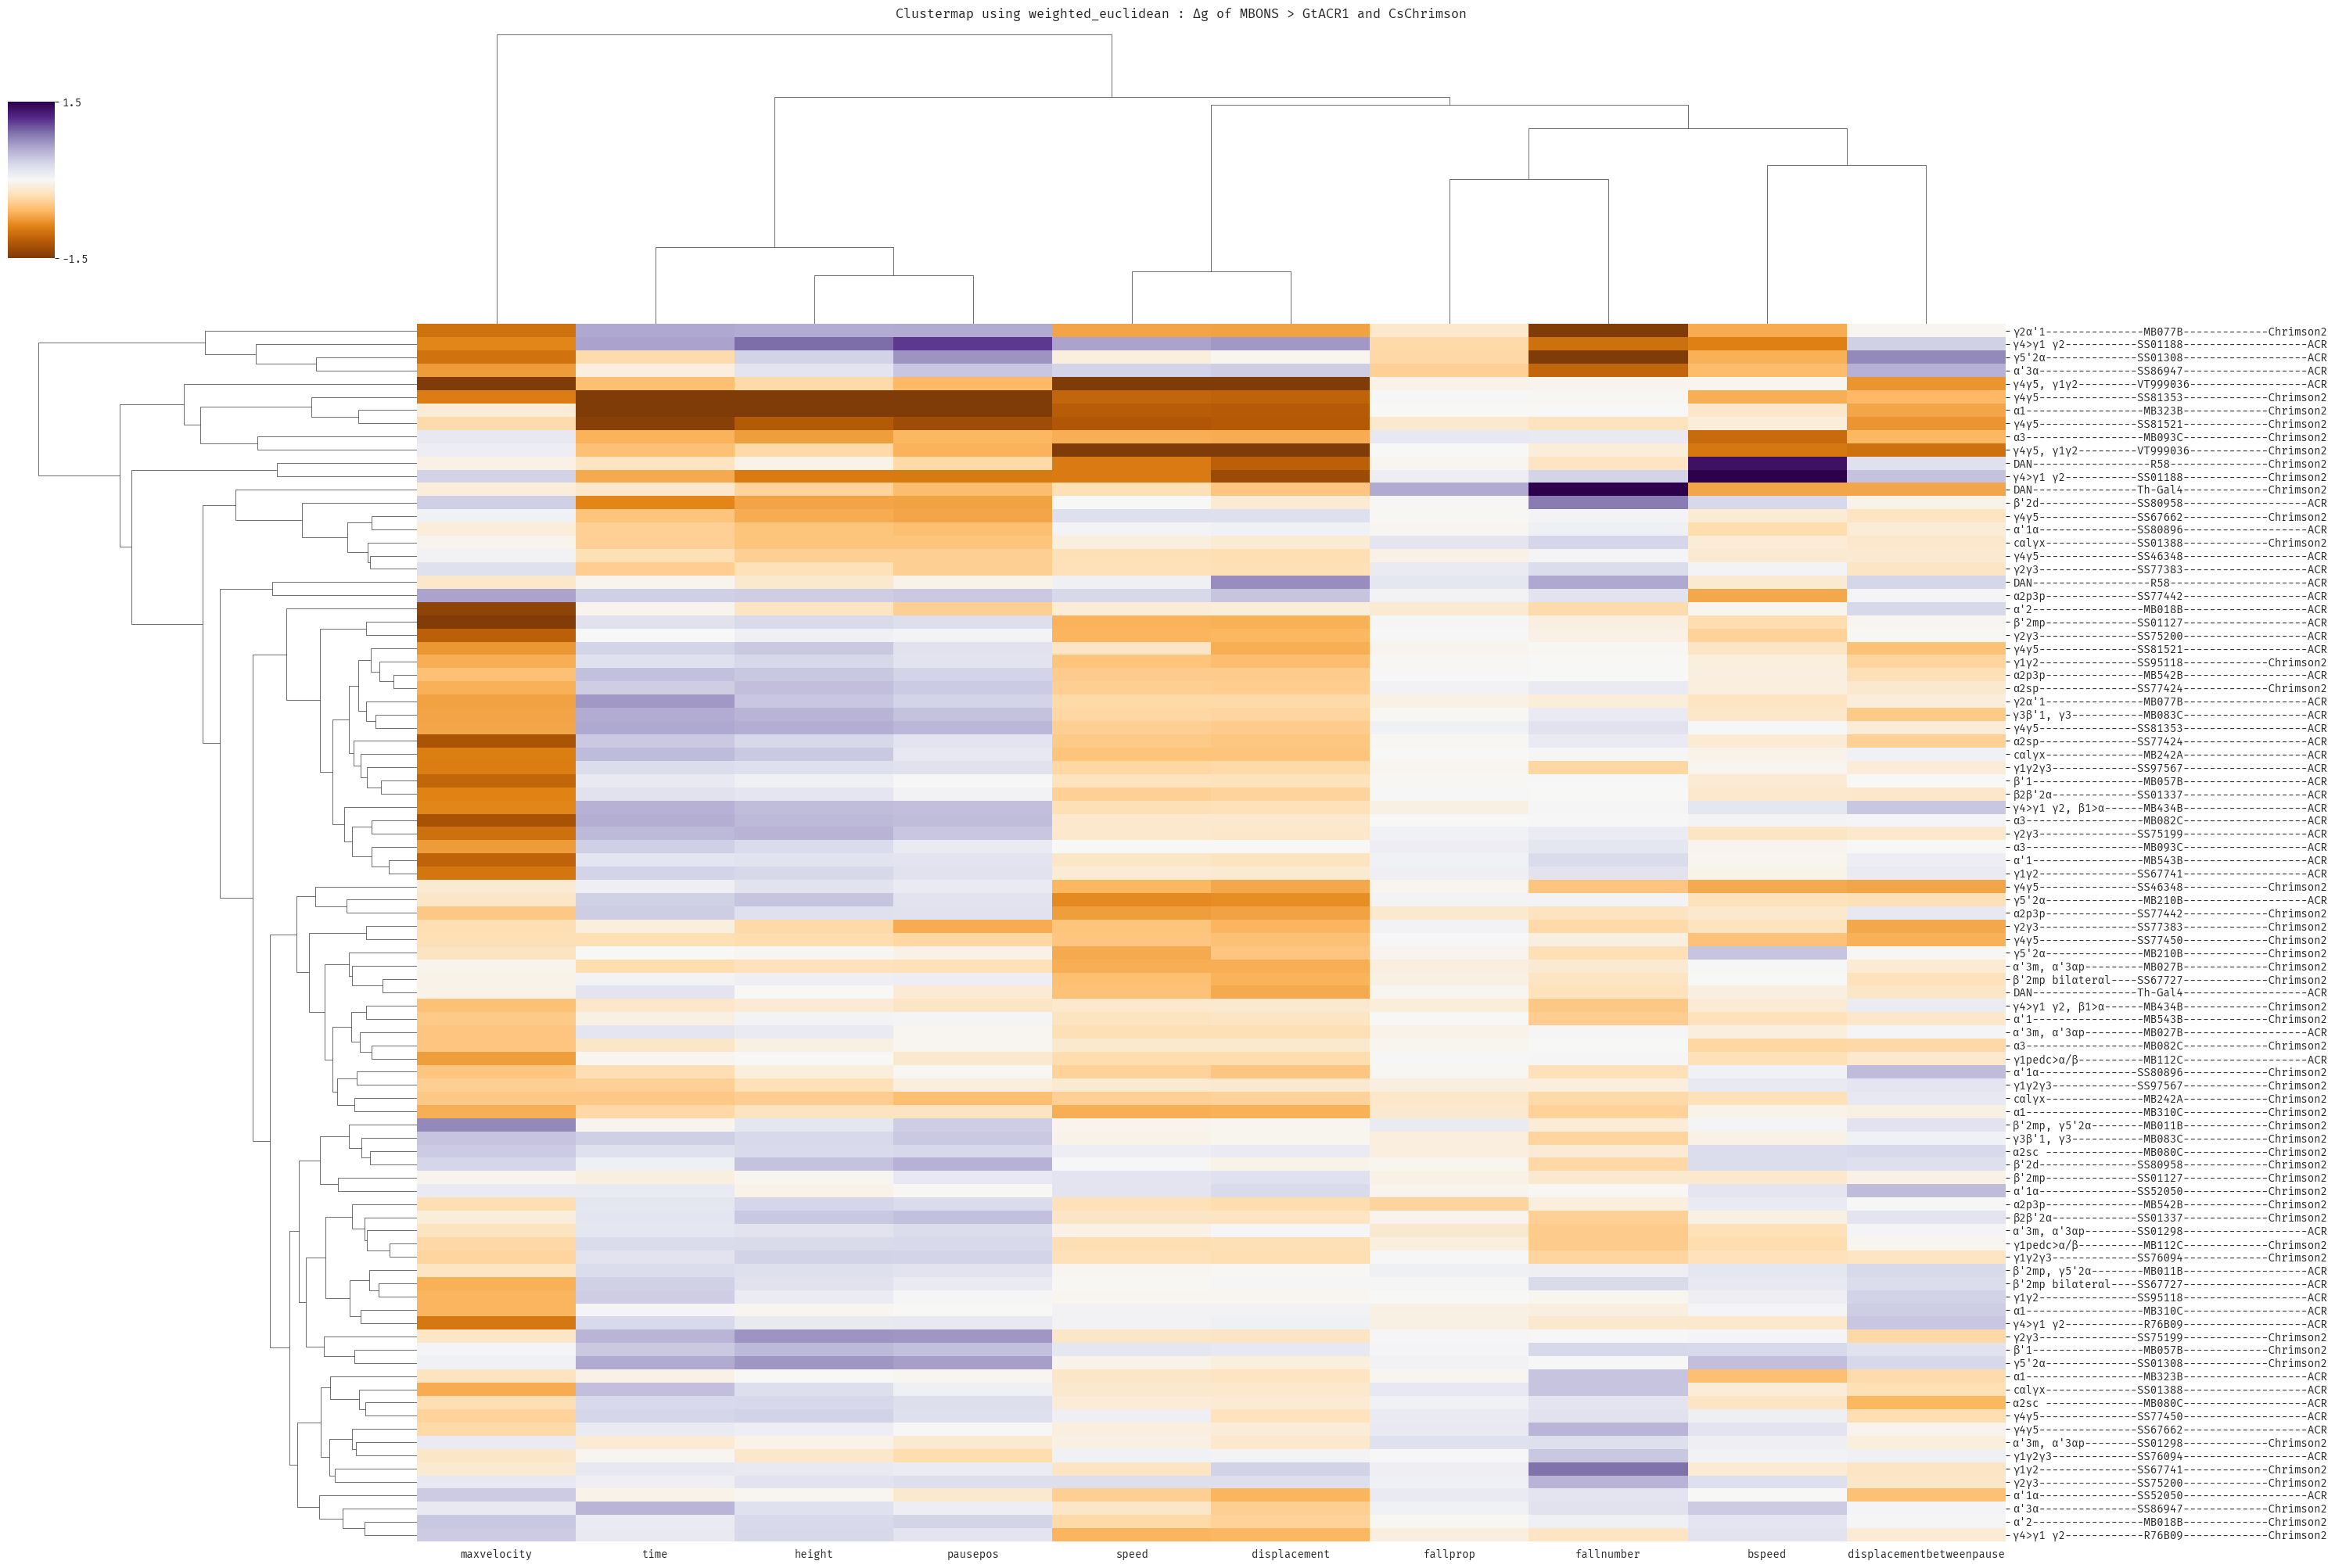

In [123]:
methodlist = ['weighted']
metriclist = ['euclidean']

   
df501 = df500.copy()
df501['totalnaming'] = df501['MBON'] + "; " + df501['responder'] + "; " + df501['Lobe']
df501newset = df501.set_index('totalnaming').iloc[:,0:11]
df501newset = df501newset.drop(["MBON"],axis =1)

ylabellist = []
for n, k, z in zip(df501['MBON'],df501['Lobe'], df501['responder']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)

plt.rcParams["font.family"] = "Fira Mono"

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df501newset, cmap= "PuOr", metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5,
                            cbar_kws = dict(shrink = 0.2, ticks = [-1.5,1.5]), figsize=(30, 20), cbar_pos=(0, 0.84, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : Δg of MBONS > GtACR1 and CsChrimson' , weight='bold', fontsize =12, y =1.0)

        #plt.rcParams["font.family"] = "Fira Mono"
        #plt.savefig(openPath + "images\\" + date + "_" + responder + "_clustermap_" + methodd + "_" + metricc + "_betweenChrimsonandACR.png", dpi = 1200)

## Heatmap (1 responder)

In [66]:
responder = "Chrimson2"

In [67]:
newfile2 = openPath + "Compilation with delta\\2025deltagcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" x ")[1].split("_")[0]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps

#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

# specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
#                    'responder', 'genotypeandresponder']

# eightmetrics = pd.DataFrame()
# for p in specificmetrics:
#     eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
# eightmetrics = eightmetrics.reset_index(drop=True)


In [68]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

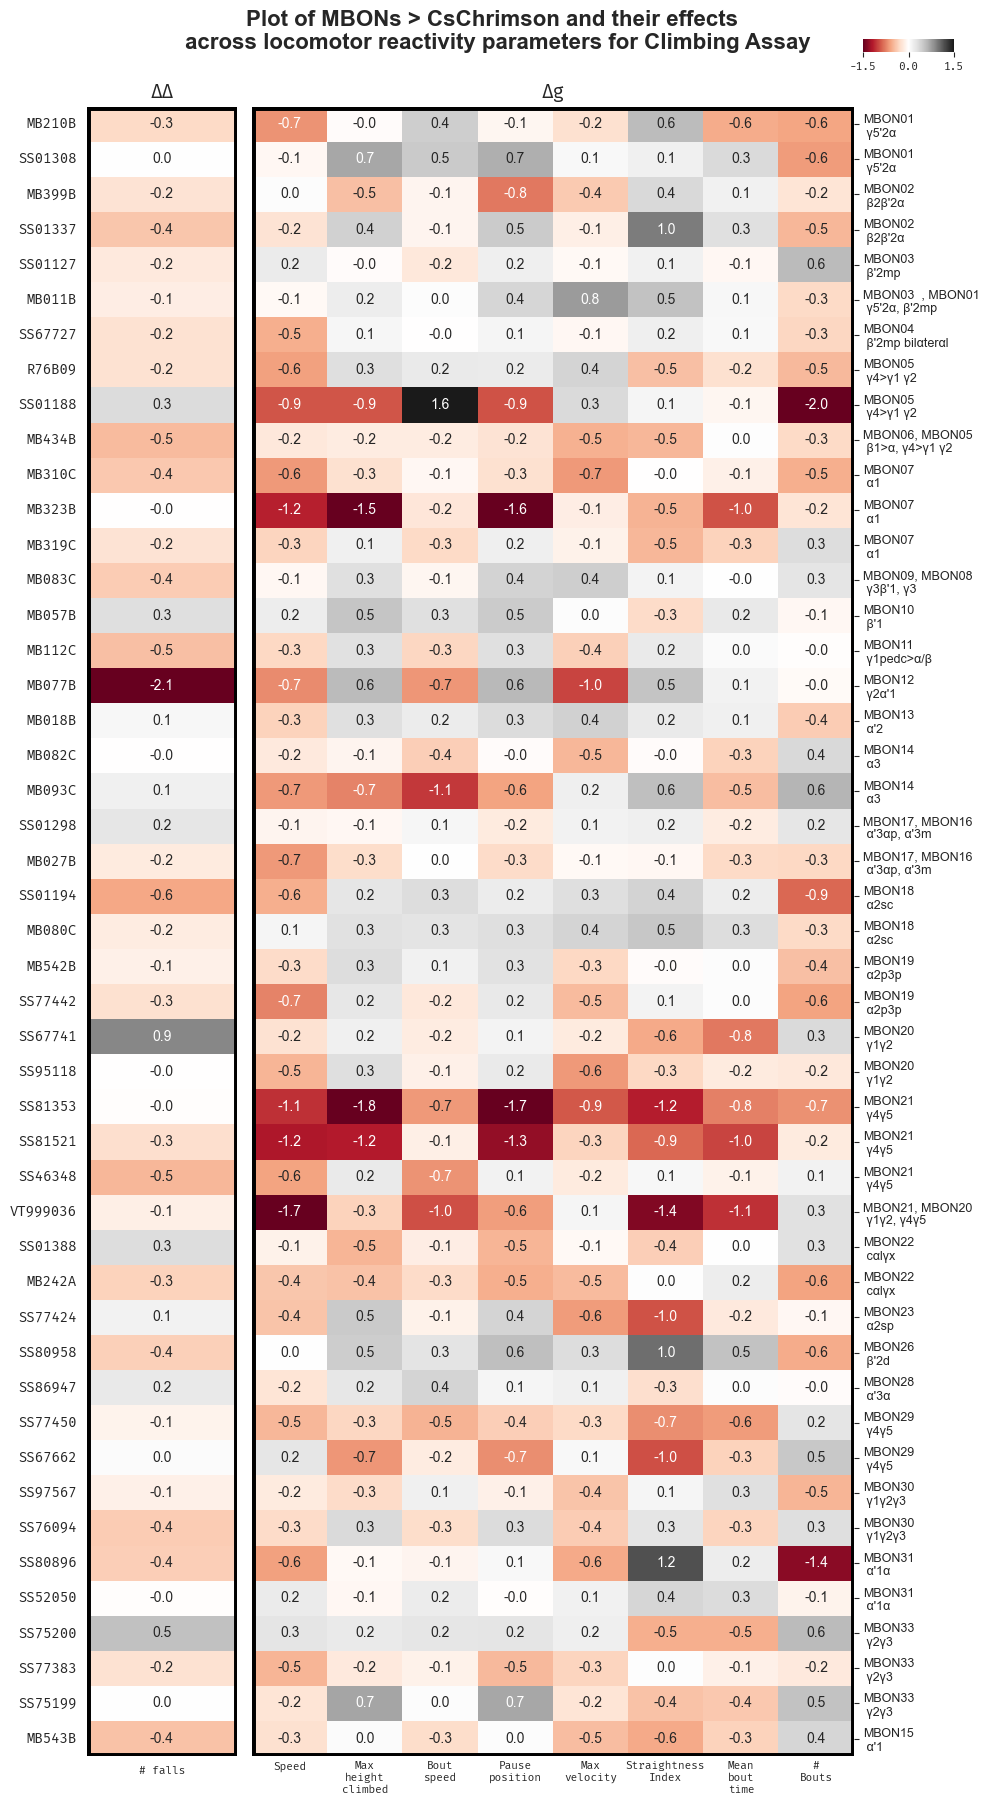

In [69]:
#mini list of only SPECIFIC responder
dfoneresponder = mbononly.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

df_specificmbon.columns = df_specificmbon.columns.str.replace('_deltag', '')
df60 = df_specificmbon.copy()
df60 = df60.set_index(['MBON']).drop(['responder'], axis =1)

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_specificmbon.copy()

for n in df_specificmbon['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True).reset_index(drop=True)

# Separate data for two subplots
# Subplot 1: Only fallnumber (Delta-delta)
df60_fallnumber = df_singleresponder_lobeloc.set_index('MBON')[['fallnumber']].copy()

# Subplot 2: All other columns (Delta-g) 
df60_other = df_singleresponder_lobeloc.set_index('MBON').drop(['responder', 'Name', 'Lobe', 'genotypeandresponder', 'fallnumber'], axis = 1).copy()

# Create figure with 2 subplots
fig1, (ax4_left, ax4_right) = plt.subplots(1, 2, figsize=(10, 18), gridspec_kw={'width_ratios': [1, 4]})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (fallnumber)
xticklabel_fallnumber = ['# falls']

# Labels for subplot 2 (other columns)
xticklabeldf_other = df60_other.rename(columns={'speed': 'Speed', 'bspeed': 'Bout speed', 'pausepos': 'Pause position', 'bout': '# Bouts', 'meanbout': "Mean bout time",
                      'straightindex': 'Straightness Index', 'height': 'Max height climbed', 'maxvelocity': 'Max velocity'})
xticklabellist_other = xticklabeldf_other.columns.tolist()

#colorbar for subplot 2
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="0.8%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.05, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: fallnumber (Delta-delta) - now with MBON names as y-labels       
j7_left = sns.heatmap(df60_fallnumber, ax = ax4_left, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, annot_kws={"size": 10, }, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabel_fallnumber, yticklabels=True,
                 clip_on=False, cbar = False)

# Subplot 2: other columns (Delta-g) - no y-labels on left side
j7_right = sns.heatmap(df60_other, ax = ax4_right, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist_other, yticklabels=True,
                 clip_on=False, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 10, })

# colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    # label.set_fontsize(10)
    label.set_family('Fira Mono')

    
# Format subplot 1
j7_left.set_ylabel('')
#j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7_left.set_xticklabels(j7_left.get_xticklabels(), fontsize = 8)
j7_left.set_title('ΔΔ', weight='bold', fontsize = 14)

# Format subplot 2
j7_right.set_ylabel('')
j7_right.set_yticklabels([], visible = False)
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize = 8)
wrap_labels(j7_right, 5)
j7_right.set_title('Δg', weight='bold', fontsize = 14)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing the frame for subplot 1
j7_left.axhline(y = 0, color = 'k', linewidth = 5) 
j7_left.axhline(y = len(df60_fallnumber), color = 'k', linewidth = 5) 
j7_left.axvline(x = 0, color = 'k', linewidth = 5) 
j7_left.axvline(x = 1, color = 'k', linewidth = 5) 

# Drawing the frame for subplot 2
j7_right.axhline(y = 0, color = 'k', linewidth = 5) 
j7_right.axhline(y = len(df60_other), color = 'k', linewidth = 5) 
j7_right.axvline(x = 0, color = 'k', linewidth = 5) 
j7_right.axvline(x = len(df60_other.columns), color = 'k', linewidth = 5) 

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = j7_right.twinx()
j8_right.set_ylim([0,j7_right.get_ylim()[0]])
j8_right.set_yticks(j7_right.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Overall title
fig1.suptitle('Plot of MBONs > ' + responderrename +' and their effects \n across locomotor reactivity parameters for Climbing Assay', x=0.5, y=1.0, weight='bold', fontsize =16)
plt.rcParams["font.family"] = "Fira Mono"
fig1.tight_layout()

plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)
plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.svg")

# Clustering

weighted euclidean


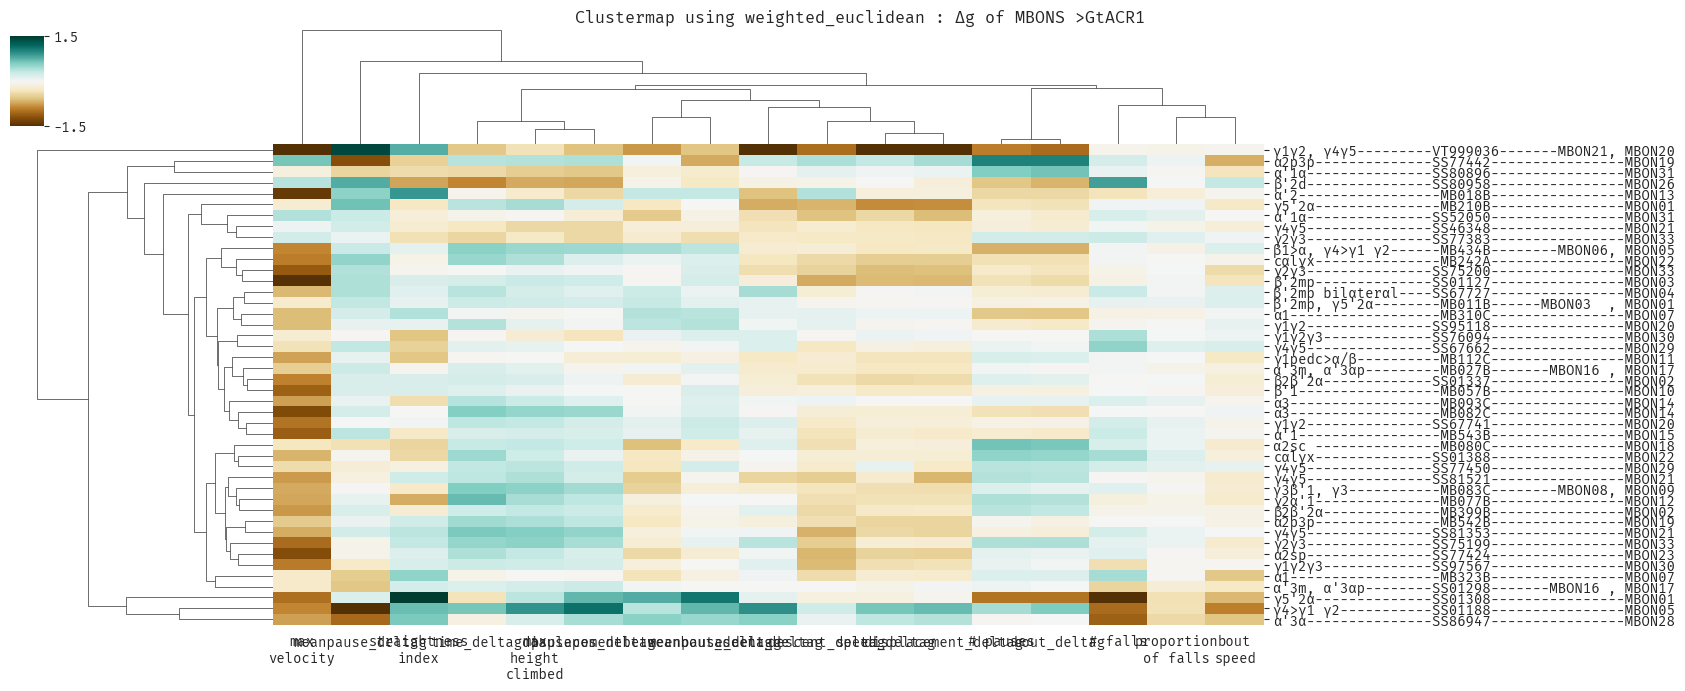

In [16]:
methodlist = ['weighted']
metriclist = ['euclidean']

if responder == 'Chrimson2':
    colormap = 'RdGy'
    
if responder == 'ACR':
    colormap = 'BrBG'
    
df601 = df600.copy()
df601['totalnaming'] = df601['MBON'] + "; " + df601['Name'] + "; " + df601['Lobe']
df601newset = df601.set_index('totalnaming').drop(['responder',	'genotypeandresponder',	'Lobe',	'Name', 'MBON'], axis = 1)

ylabellist = []
for n, k, z in zip(df601['MBON'],df601['Lobe'], df601['Name']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)
    
xticklabeldf = df601newset.rename(columns={'bspeed_deltag': 'bout speed', 'pause_deltag': '# pauses', 'fallnumber_deltag': '# falls', 
                     'fallprop_deltag': "proportion of falls", 'straightindex_deltag': 'straightness index', 'height_deltag': 'max height climbed', 'maxvelocity_deltag': 'max velocity'})

xticklabellist = xticklabeldf.columns.tolist()

plt.rcParams["font.family"] = "Fira Mono"

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df601newset, cmap=colormap, metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5, xticklabels=xticklabellist,
                            cbar_kws = dict(shrink = 0.15, ticks = [-1.5,1.5]), figsize=(17, 9), cbar_pos=(0, 0.87, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : Δg of MBONS >' + responderrename , weight='bold', fontsize =12, y =1.0)

        #plt.rcParams["font.family"] = "Fira Mono"
        plt.savefig(openPath + "images\\" + date + "_" + responder + "_clustermap_" + methodd + "_" + metricc + ".png", dpi = 1200)